In [7]:
import h5py
import numpy as np
import pandas as pd
# 读取 HDF5 文件
with h5py.File(r'D:\NJF\neuro_decoding\decoding_20240301\first\day1/Samples.h5', 'r') as f:
    Sample = f['/dataset'][:]
with h5py.File(r'D:\NJF\neuro_decoding\decoding_20240301\first\day1/Timestamps.h5', 'r') as f:
    Timestamps = f['/dataset'][:]
with h5py.File(r'D:\NJF\neuro_decoding\decoding_20240301\first\day1/labels.h5', 'r') as f:
    labels = f['/dataset'][:]    
# 现在 data 是一个 numpy 数组，包含了 Samples 的数据

In [8]:
from tsai.all import *
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn import *
import glob
import os
import pathlib
import re
import pickle
from sklearn.metrics import classification_report

In [9]:
Sample.shape

(13353, 15)

In [10]:
labels.shape

(13353, 1)

In [11]:
Timestamps.shape

(13353, 1)

In [12]:
data = np.concatenate((Sample, labels), axis=1)
data.shape
# 第16列是标签，前15列是15个通道的数据，按照512先做了降采样

(13353, 16)

In [13]:
df = pd.DataFrame(data)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.449219,0.951172,1.896484,2.117188,2.175781,1.679688,0.769531,1.070312,0.986328,2.130859,2.083984,1.964844,-0.007812,0.210938,2.359375,0.0
1,-0.146484,-0.482422,-1.230469,-1.621094,-1.292969,-1.458984,-0.919922,-0.294922,-0.533203,-1.669922,-1.414062,-1.089844,-0.195312,-0.468750,-1.765625,0.0
2,-0.802734,-1.447266,-2.435547,-2.572266,-2.576172,-2.236328,-1.345703,-1.476562,-1.416016,-2.523438,-2.572266,-2.845703,-0.751953,-1.027344,-2.525391,0.0
3,-0.031250,0.326172,0.685547,0.755859,-0.265625,-0.621094,-0.859375,-2.210938,0.308594,0.923828,0.589844,-0.044922,-0.162109,-0.597656,-2.373047,0.0
4,0.660156,0.777344,1.447266,1.580078,2.800781,3.679688,3.291016,5.156250,0.730469,1.341797,1.683594,3.380859,1.591797,2.392578,6.126953,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13348,-0.757812,-1.447266,-2.830078,-3.105469,-3.386719,-2.761719,-1.197266,-2.445312,-1.492188,-2.982422,-3.050781,-3.042969,-0.060547,-0.527344,-4.373047,0.0
13349,0.085938,-0.365234,-0.654297,-0.726562,-0.242188,-0.121094,0.343750,-0.203125,-0.314453,-0.591797,-0.718750,-0.087891,1.115234,0.880859,-1.546875,0.0
13350,-0.156250,-0.390625,-0.292969,-0.289062,-0.974609,-1.144531,-1.900391,-2.056641,-0.386719,-0.310547,-0.289062,-1.291016,-2.548828,-2.150391,-0.753906,0.0
13351,1.027344,2.921875,4.785156,4.912109,5.712891,5.257812,3.490234,5.210938,2.919922,4.972656,4.900391,5.628906,1.820312,2.240234,7.218750,0.0


In [14]:
def merge_ndarrays(arrays):
    return np.concatenate(arrays, axis=0)

def My_Sliding_window(data, window_size, sample,event_threshold,vars):
    # 前后时间序列补0 静态数据补均值（就一个值）
    df = data.drop(data.columns[-1], axis=1) #移除最后一列，即标签列
    num_rows = df.shape[0] #获取df的行数
    # 检查数据总行数能否被采样率整除，若是则最后一次采样后剩余的数据可以被完全使用，不会导致起始和结束处的窗口特征不完整
    if num_rows % sample == 0:
        flag_result = 1
    else: # 不能整除
        flag_result = 0    
    number = (window_size - 1) // 2 # 获取窗口中心位置相对于窗口两端的偏移量
    # 为了保证滑动窗口的起始和结束处都有足够的数据而填充0
    zeros_data = np.zeros((number, df.shape[1])) #创建一个全0数组
    zeros_df = pd.DataFrame(zeros_data, columns=df.columns)
    df = pd.concat([zeros_df, df, zeros_df]) # 将全0数组添加到第一行之前和最后一行之后
    
    # 得到预期特征数组，共三个维度（窗口数，特征数，窗口大小）
    if flag_result == 1:
        new_data = np.zeros((num_rows//sample, vars, window_size))
    elif flag_result == 0:
        new_data = np.zeros(((num_rows // sample)+1, vars, window_size))  
    
    new_data_y = pd.DataFrame()
    # 循环迭代处理数据中的每个窗口，这个范围从窗口的一半大小开始，到最后一个窗口结束，步长为sample
    for i in range(int((window_size - 1) / 2), num_rows + int((window_size - 1) / 2),sample):
        # 提取数据中的滑动窗口，将这些窗口的数据存储到new_data中
        X = df.iloc[i - int((window_size - 1) / 2):i + int((window_size - 1) / 2) + 1, :]
        if X.shape != (window_size, vars):
            print('error 1')
        new_data[(i-number)//sample, :, :] = X.T            

        # 为每个窗口确定相应的标签值y，并将其添加到‘new_data_y'中
        event_threshold_count = sample * event_threshold
        target_counts = data.iloc[i:i + sample].iloc[:,-1].value_counts()
        # 判断数量是否符合要求，决定 y 的值
        if target_counts.get(1,0) > event_threshold_count:
            y = 1
        else:
            y = 0
        new_data_y = new_data_y.append(pd.DataFrame([y]), ignore_index=True)
        
    return new_data ,new_data_y.values.reshape(-1)

In [18]:
X_list = []
y_list = []
window_length = 101 # 这里目前必须是奇数，表示一次性处理的行数
stride = 20 # 滑动窗口的步长，表示每次向下滑动的行数
event_threshold = 0.5 #若判断大于0.5则说明事件发生
var = 15

X,y = My_Sliding_window(data = df,window_size=window_length, sample=stride,event_threshold = event_threshold,vars = var)

# 用于将数据转化为机器学习模型可以使用的格式：从数据中提取特征并生成相应的标签
X_list.append(X)
y_list.append(y)
X_all = merge_ndarrays(X_list)
y_all = merge_ndarrays(y_list)

In [19]:
X_all.shape

(668, 15, 101)

In [20]:
y_all.shape

(668,)

In [33]:
# 5折交叉验证
from sklearn.model_selection import StratifiedKFold
# skf = StratifiedKFold(n_splits=5, shuffle=False)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=23)

In [31]:
# y_series = pd.Series(y_all)
y_series = pd.Series(y_all)
# 统计每个值的数量，并计算比例
target_counts = y_series.value_counts()
target_total = target_counts.sum()
target0_ratio = np.float32(target_counts[0] / target_total)
target1_ratio = np.float32(target_counts[1] / target_total)


In [32]:
print(target0_ratio)
print(target1_ratio)


0.815534
0.18446602


[    0     3     4 ... 11377 11378 11381]
[    1     2    20 ... 11375 11379 11380]
验证集0 1：
0.7400088
0.25999123
训练集0 1：
0.740033
0.25996706


epoch,train_loss,valid_loss,accuracy,time
0,0.567365,0.530976,0.764163,00:04
1,0.488019,0.446151,0.797101,00:04
2,0.441927,0.419930,0.812912,00:04
3,0.415106,0.417884,0.812473,00:04
4,0.379384,0.389495,0.829161,00:04
5,0.325507,0.346284,0.849363,00:04
6,0.269744,0.249312,0.903382,00:04
7,0.228627,0.194736,0.920070,00:04
8,0.188646,0.182556,0.935002,00:04
9,0.156348,0.166180,0.938076,00:04


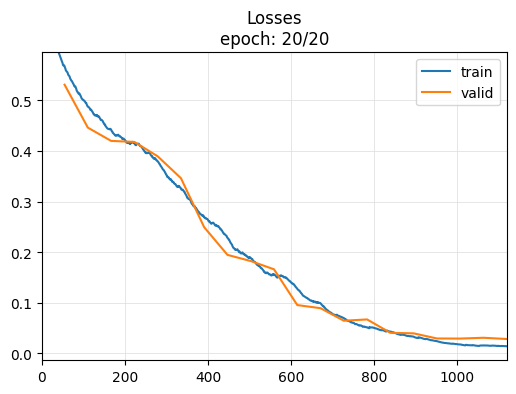

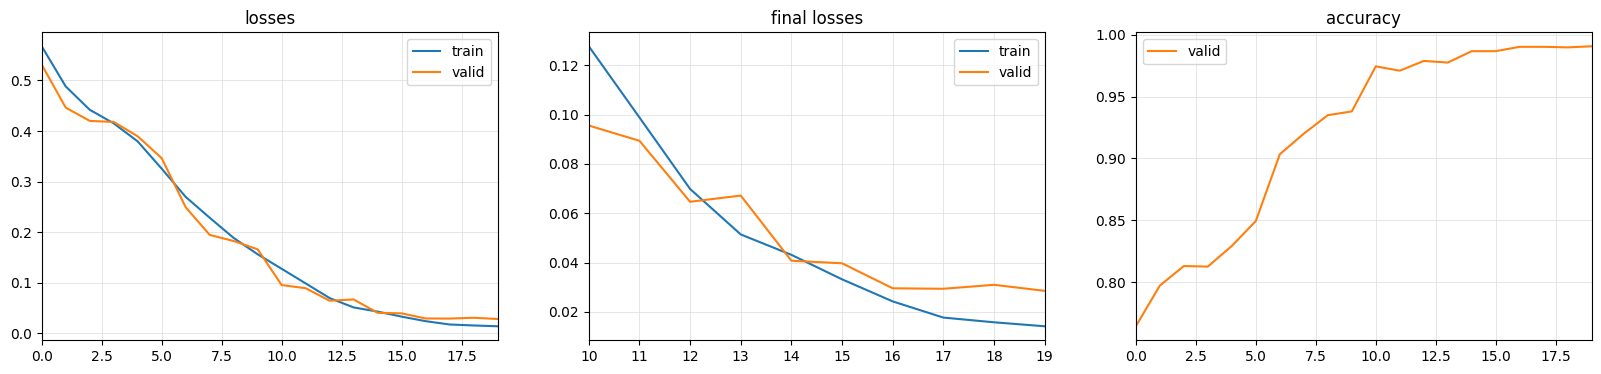

[    0     1     2 ... 11379 11380 11381]
[   11    15    16 ... 11370 11371 11374]
验证集0 1：
0.7400088
0.25999123
训练集0 1：
0.740033
0.25996706


epoch,train_loss,valid_loss,accuracy,time
0,0.573298,0.521079,0.769873,00:04
1,0.492674,0.454548,0.794027,00:04
2,0.450183,0.444569,0.797541,00:04
3,0.413351,0.393999,0.821256,00:04
4,0.372068,0.357549,0.848924,00:04
5,0.337458,0.317754,0.864734,00:04
6,0.284016,0.304098,0.866930,00:04
7,0.235834,0.232470,0.900307,00:04
8,0.199872,0.174576,0.937637,00:04
9,0.170450,0.198657,0.913043,00:04


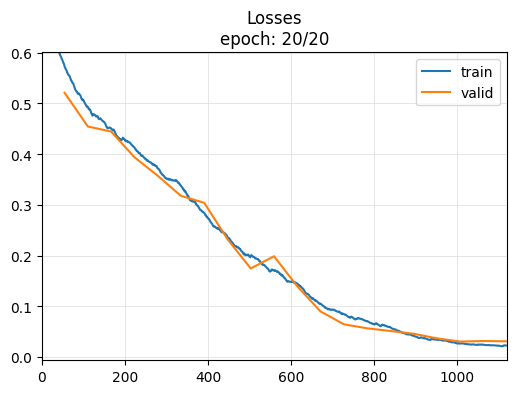

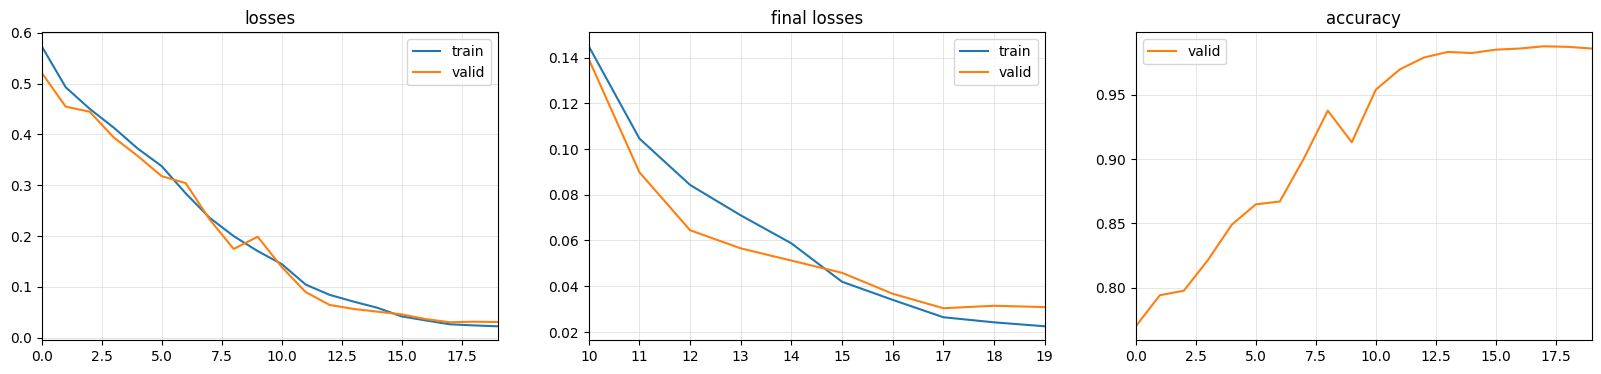

[    0     1     2 ... 11379 11380 11381]
[   12    13    19 ... 11369 11377 11378]
验证集0 1：
0.7403339
0.2596661
训练集0 1：
0.73995167
0.26004833


epoch,train_loss,valid_loss,accuracy,time
0,0.628647,0.544940,0.760984,00:04
1,0.523925,0.486788,0.771529,00:04
2,0.469798,0.430726,0.814587,00:04
3,0.422408,0.406298,0.815905,00:04
4,0.385812,0.349499,0.851054,00:04
5,0.349159,0.311849,0.885764,00:04
6,0.294978,0.276206,0.891037,00:04
7,0.268286,0.234839,0.905536,00:04
8,0.219735,0.220387,0.909930,00:04
9,0.169009,0.166651,0.934974,00:04


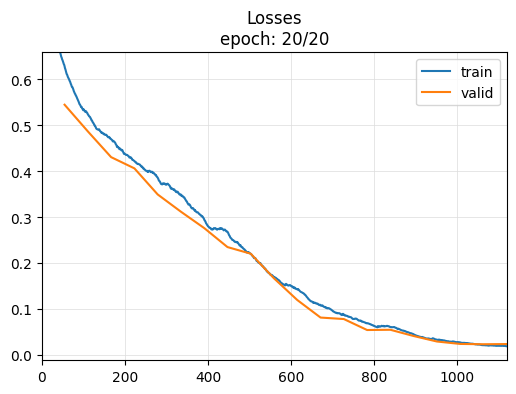

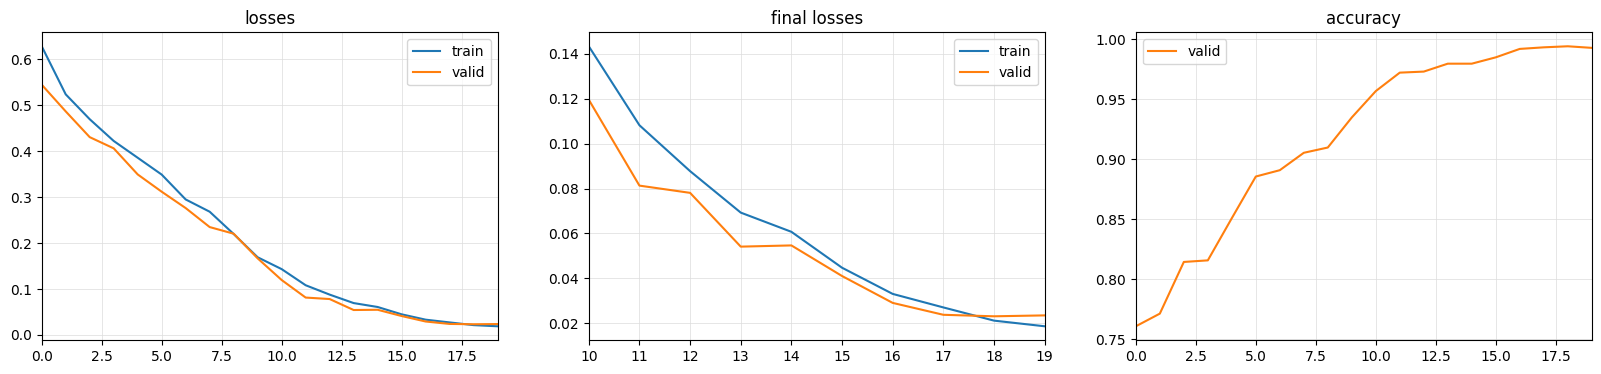

[    1     2     4 ... 11378 11379 11380]
[    0     3     5 ... 11372 11373 11381]
验证集0 1：
0.73989457
0.26010546
训练集0 1：
0.7400615
0.2599385


epoch,train_loss,valid_loss,accuracy,time
0,0.611588,0.541213,0.764060,00:04
1,0.507607,0.502252,0.774605,00:04
2,0.454171,0.430545,0.807557,00:04
3,0.420768,0.409088,0.822496,00:04
4,0.373573,0.336561,0.854569,00:04
5,0.326406,0.303187,0.866432,00:04
6,0.279171,0.257932,0.905975,00:04
7,0.233979,0.231634,0.907293,00:04
8,0.211418,0.183307,0.928823,00:04
9,0.170586,0.138050,0.960018,00:04


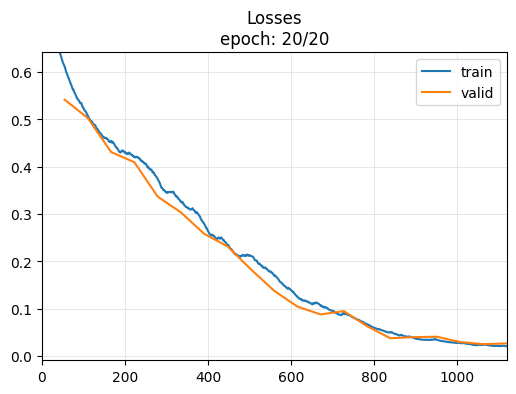

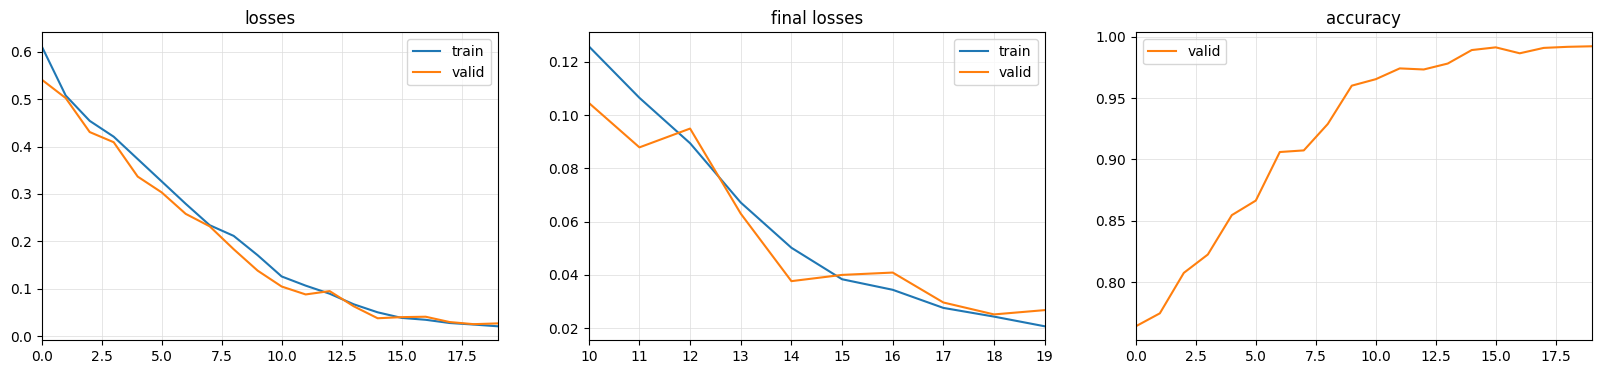

[    0     1     2 ... 11379 11380 11381]
[    4    10    17 ... 11362 11365 11376]
验证集0 1：
0.73989457
0.26010546
训练集0 1：
0.7400615
0.2599385


epoch,train_loss,valid_loss,accuracy,time
0,0.572880,0.533431,0.771529,00:04
1,0.497930,0.466882,0.793058,00:04
2,0.451411,0.456367,0.807557,00:04
3,0.421067,0.416993,0.808436,00:04
4,0.380440,0.332681,0.865993,00:04
5,0.335134,0.334140,0.865993,00:04
6,0.299569,0.305857,0.856327,00:04
7,0.260841,0.251436,0.907733,00:04
8,0.214228,0.219744,0.915641,00:04
9,0.176630,0.222108,0.910808,00:04


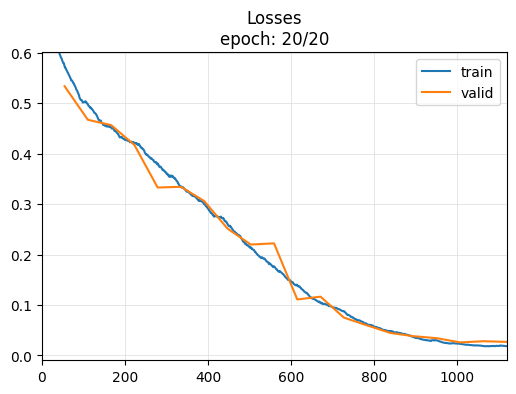

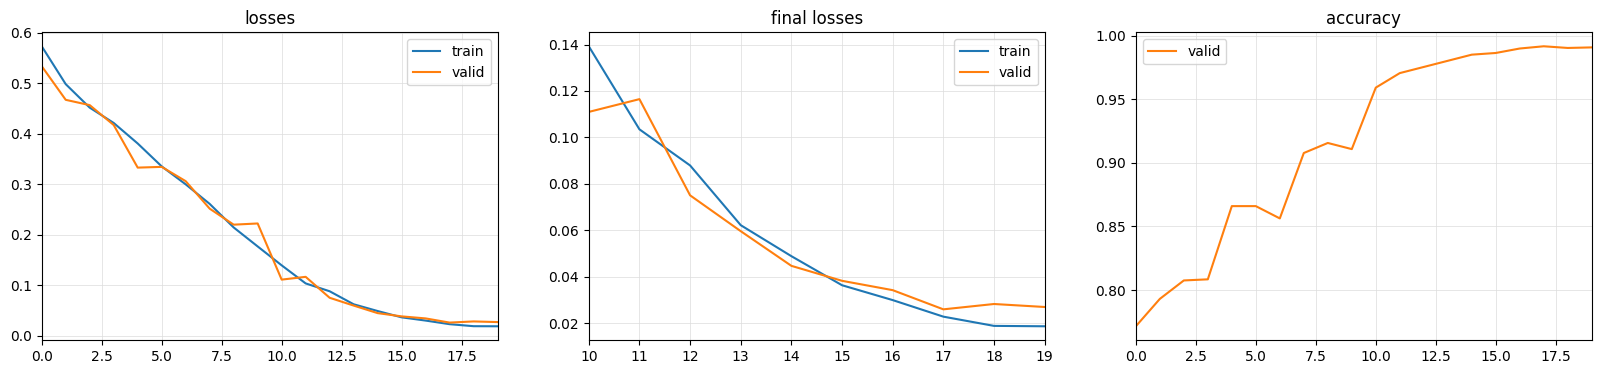

In [36]:
for train_index, valid_index in skf.split(X_all, y_all):
    # 使用当前折的训练数据和验证数据创建数据集
    print(train_index)
    print(valid_index)
#     print(y_all[train_index].shape)
    y_series = pd.Series(y_all[valid_index])
    # 统计每个值的数量，并计算比例
    target_counts = y_series.value_counts()
    target_total = target_counts.sum()
    target0_ratio = np.float32(target_counts[0] / target_total)
    target1_ratio = np.float32(target_counts[1] / target_total)
    print('验证集0 1：')
    print(target0_ratio)
    print(target1_ratio)
    
    
    
    
    y_series = pd.Series(y_all[train_index])
    # 统计每个值的数量，并计算比例
    target_counts = y_series.value_counts()
    target_total = target_counts.sum()
    target0_ratio = np.float32(target_counts[0] / target_total)
    target1_ratio = np.float32(target_counts[1] / target_total)
    print('训练集0 1：')
    print(target0_ratio)
    print(target1_ratio)
    
    
    
    
    
    
#     splits = get_splits(y_all[train_index], valid_size =.2, stratify=True, random_state=23, shuffle=False)
    tfms  = [None, [Categorize()]]
#     dsets = TSDatasets(X_all[train_index], y_all[train_index], tfms=tfms, splits=(train_index, valid_index), inplace=True)
    dsets = TSDatasets(X_all, y_all, tfms=tfms, splits=(train_index, valid_index), inplace=True)
   
    dls = TSDataLoaders.from_dsets(dsets.train, dsets.valid, bs=160, batch_tfms=[TSStandardize(by_var=True)])
    
    
    
    
    # 创建模型和Learner
    model = InceptionTime(dls.vars, dls.c)
    learn = Learner(dls, model, metrics=accuracy, cbs=ShowGraphCallback2())
#     learn.save('stage0')
#     learn.load('stage0')
#     learn.lr_find()
    learn.fit_one_cycle(20, 8*1e-4)
    

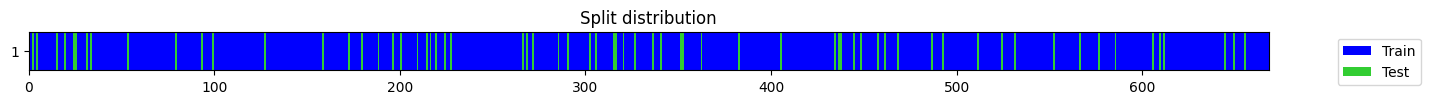

(#668) [(TSTensor(vars:15, len:101, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:15, len:101, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:15, len:101, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:15, len:101, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:15, len:101, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:15, len:101, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:15, len:101, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:15, len:101, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:15, len:101, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:15, len:101, device=cpu, dtype=torch.float32), TensorCategory(0))] ...]

In [21]:
# 准备时间序列数据集，包括对特征数据和标签数据的转换以及拆分为训练集和验证集
splits = get_splits(y_all, valid_size=.1, stratify=True, random_state=27, shuffle=True)
# splits = get_splits(y_all, valid_size =.1, stratify=True, random_state=23, shuffle=False)

# 将标签数据转换为分类类别
tfms  = [None, [Categorize()]]
# 创建一个时间序列数据集对象
dsets = TSDatasets(X_all, y_all, tfms=tfms, splits=splits, inplace=True)
dsets

In [22]:
# 创建一个时间序列加载器对象，用于加载准备好的训练集和验证集到模型中
dls = TSDataLoaders.from_dsets(dsets.train, dsets.valid, bs=160, batch_tfms=[TSStandardize(by_var=True)])

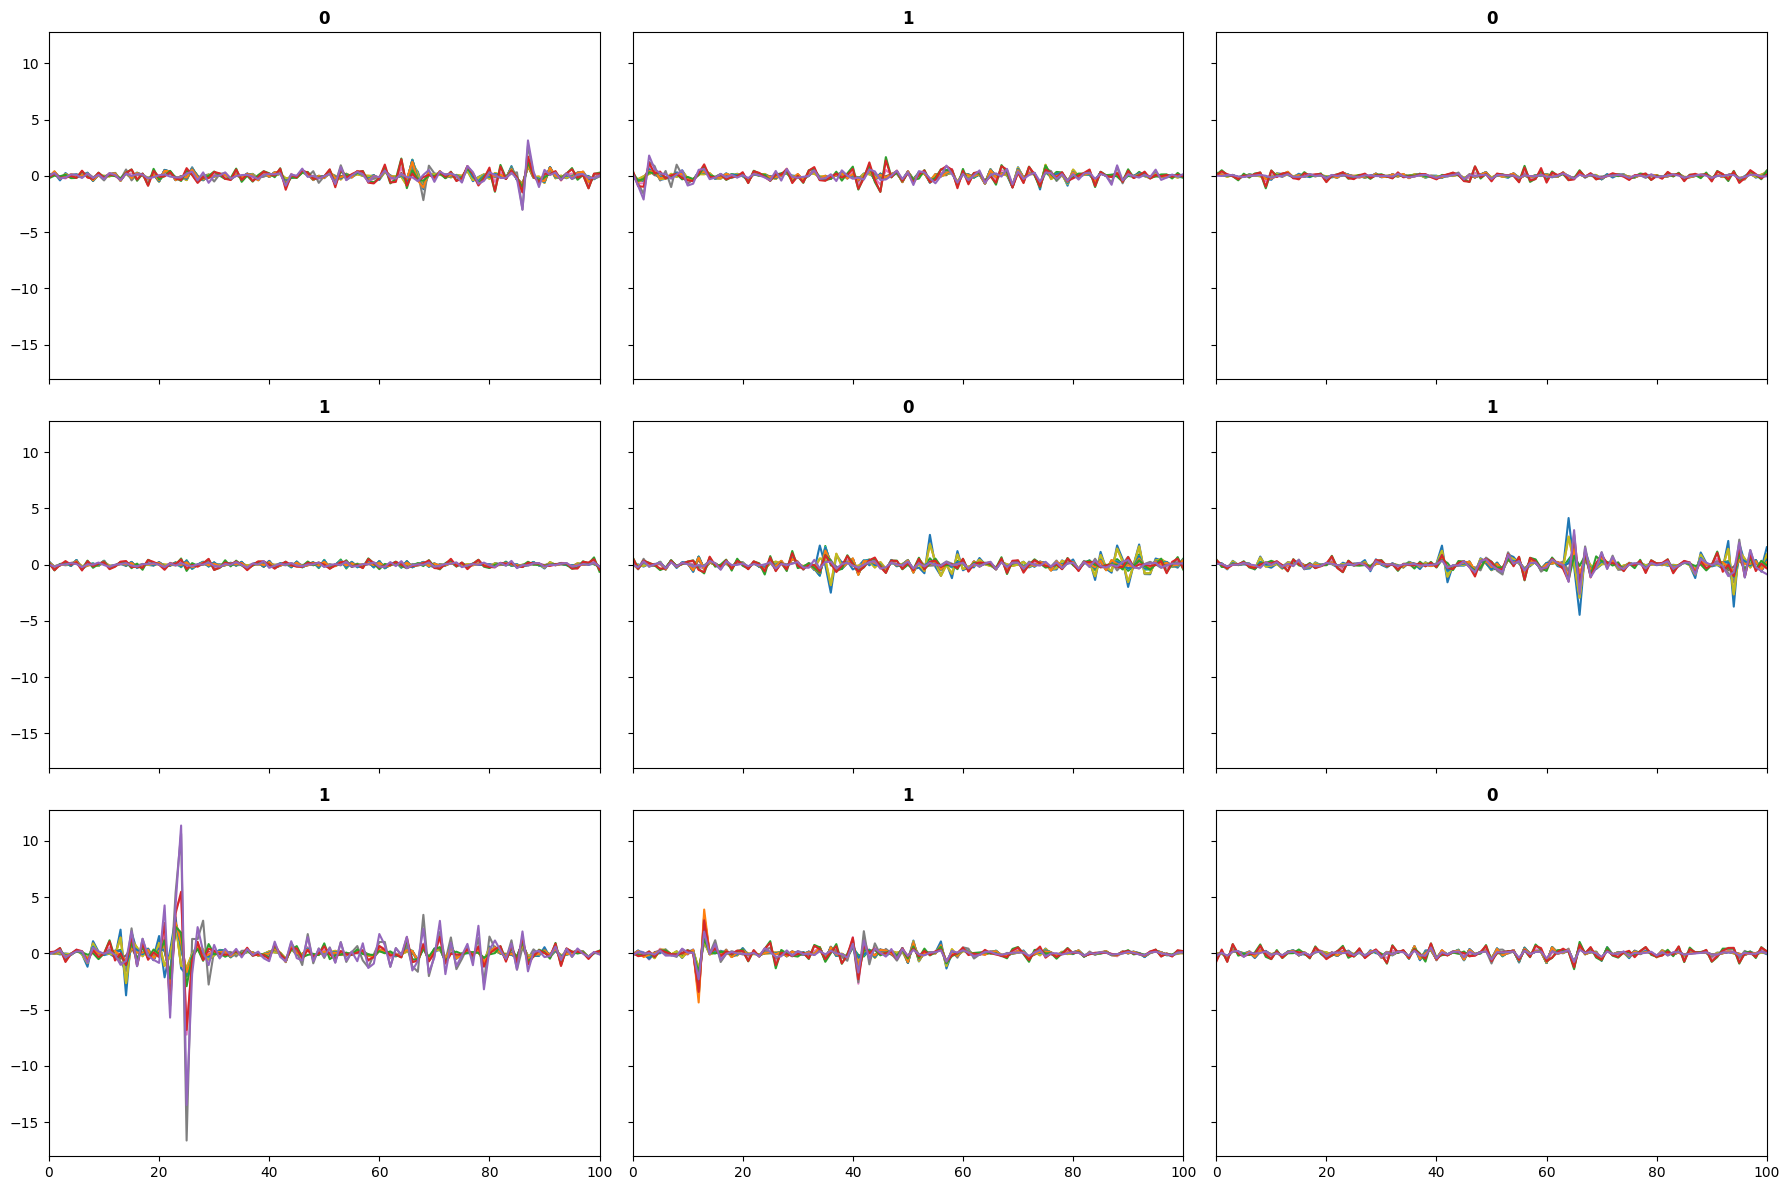

In [23]:
# 显示数据加载器dls中一个批次的数据示例
dls.show_batch(sharey=True)

In [24]:
# 创建一个神经网络模型
model = InceptionTime(dls.vars, dls.c)

learn = Learner(dls, model, metrics=accuracy,  cbs=ShowGraphCallback2())

SuggestedLRs(valley=0.0012022644514217973)

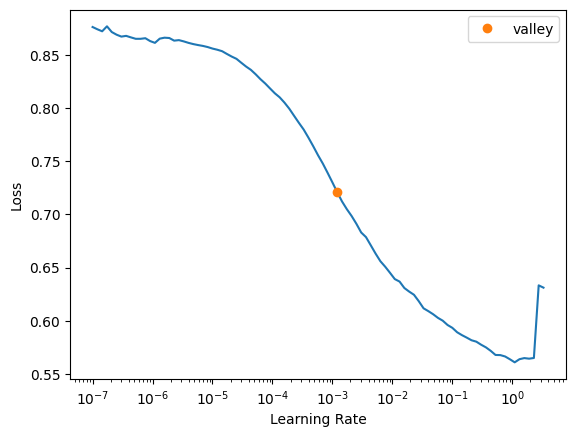

In [34]:
# learn.load('stage0')
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,time
0,0.702336,0.708352,0.454545,00:09
1,0.692747,0.706671,0.454545,00:00
2,0.682039,0.705206,0.454545,00:00
3,0.672400,0.703868,0.454545,00:00
4,0.660038,0.701900,0.454545,00:00
5,0.650761,0.699457,0.454545,00:00
6,0.638405,0.695863,0.454545,00:00
7,0.629800,0.680590,0.500000,00:00
8,0.615659,0.643476,0.636364,00:00
9,0.599895,0.646200,0.575758,00:00


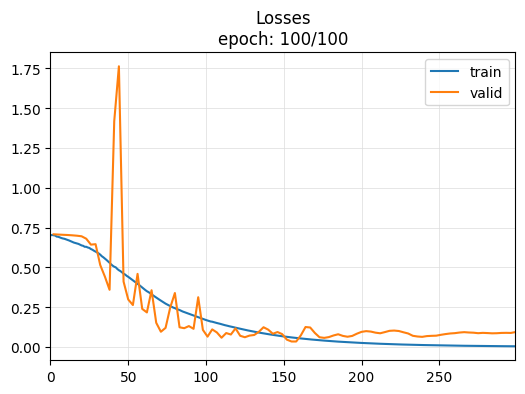

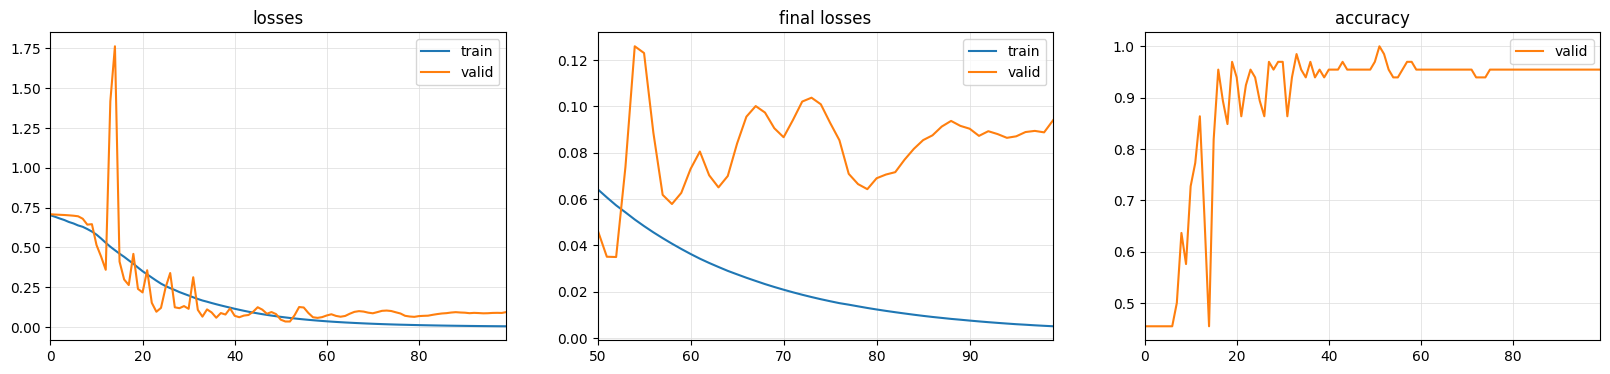

In [25]:
# 训练100周期，初始学习率为8*1e-4
learn.fit_one_cycle(100, 8*1e-4)

In [25]:
# 导出训练好的模型以便在其他地方部署
learn.export(fname='onlyexport/model_InceptionTime.pkl')

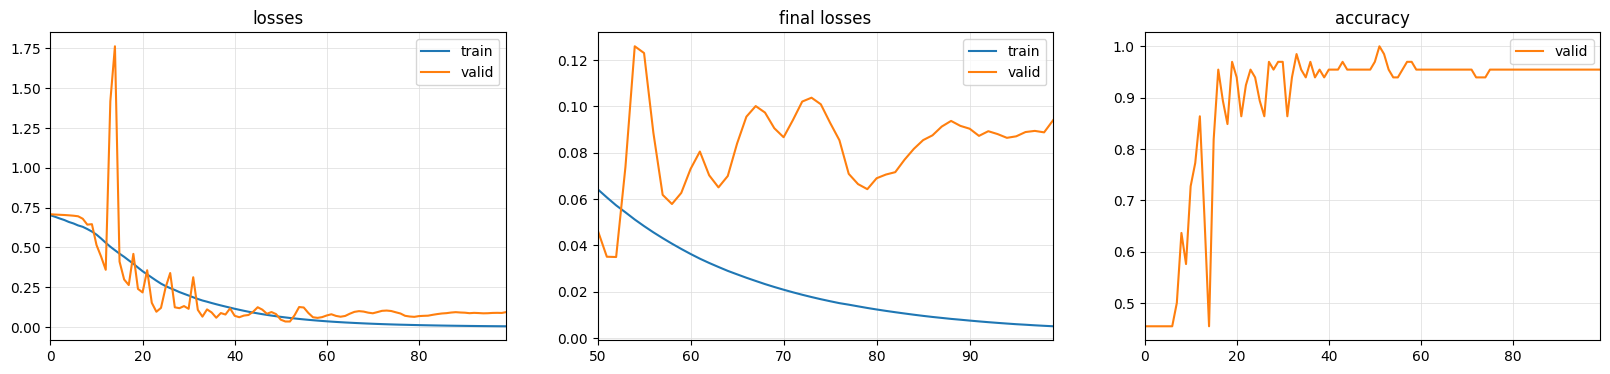

In [26]:
# 绘制训练过程中指定的评估指标的曲线图
learn.recorder.plot_metrics()

In [27]:
# 获取验证集的预测结果
valid_dl = dls.valid
valid_probas, valid_targets, valid_preds = learn.get_preds(dl=valid_dl, with_decoded=True)
valid_probas, valid_targets, valid_preds

(TensorBase([[2.7782e-04, 9.9972e-01],
             [9.9966e-01, 3.4026e-04],
             [8.6344e-04, 9.9914e-01],
             [9.9675e-01, 3.2452e-03],
             [2.4486e-04, 9.9976e-01],
             [1.6098e-03, 9.9839e-01],
             [1.7691e-03, 9.9823e-01],
             [9.9869e-01, 1.3073e-03],
             [1.9100e-03, 9.9809e-01],
             [1.5492e-04, 9.9985e-01],
             [9.0656e-01, 9.3435e-02],
             [5.6797e-03, 9.9432e-01],
             [9.9899e-01, 1.0094e-03],
             [9.9991e-01, 9.3180e-05],
             [3.4228e-04, 9.9966e-01],
             [2.5645e-04, 9.9974e-01],
             [8.3904e-02, 9.1610e-01],
             [9.9879e-01, 1.2127e-03],
             [1.5594e-01, 8.4406e-01],
             [1.4782e-03, 9.9852e-01],
             [1.6262e-03, 9.9837e-01],
             [9.9946e-01, 5.3522e-04],
             [1.0847e-03, 9.9892e-01],
             [5.6600e-03, 9.9434e-01],
             [9.9937e-01, 6.2722e-04],
             [9.9978e-01,

In [28]:
#计算验证集中类别标签的比例
after_target_counts = valid_targets.numpy()
after_target_counts = pd.DataFrame(after_target_counts)
after_target_counts = after_target_counts.value_counts()
target_total = after_target_counts.sum()
target0_ratio = np.float32(after_target_counts[0] / target_total)
target1_ratio = np.float32(after_target_counts[1] / target_total)

print(target0_ratio)
print(target1_ratio)
print(target_total)

0.45454547
0.54545456
66


In [29]:
# 对验证集样本的预测结果
valid_preds

TensorBase([1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,
            1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
            1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1])

In [30]:
# 获得准确率
acc = accuracy_multi(valid_preds, valid_targets)
acc

TensorBase(0.9545)

In [31]:
(valid_targets == valid_preds).float().mean()

TensorBase(0.9545)

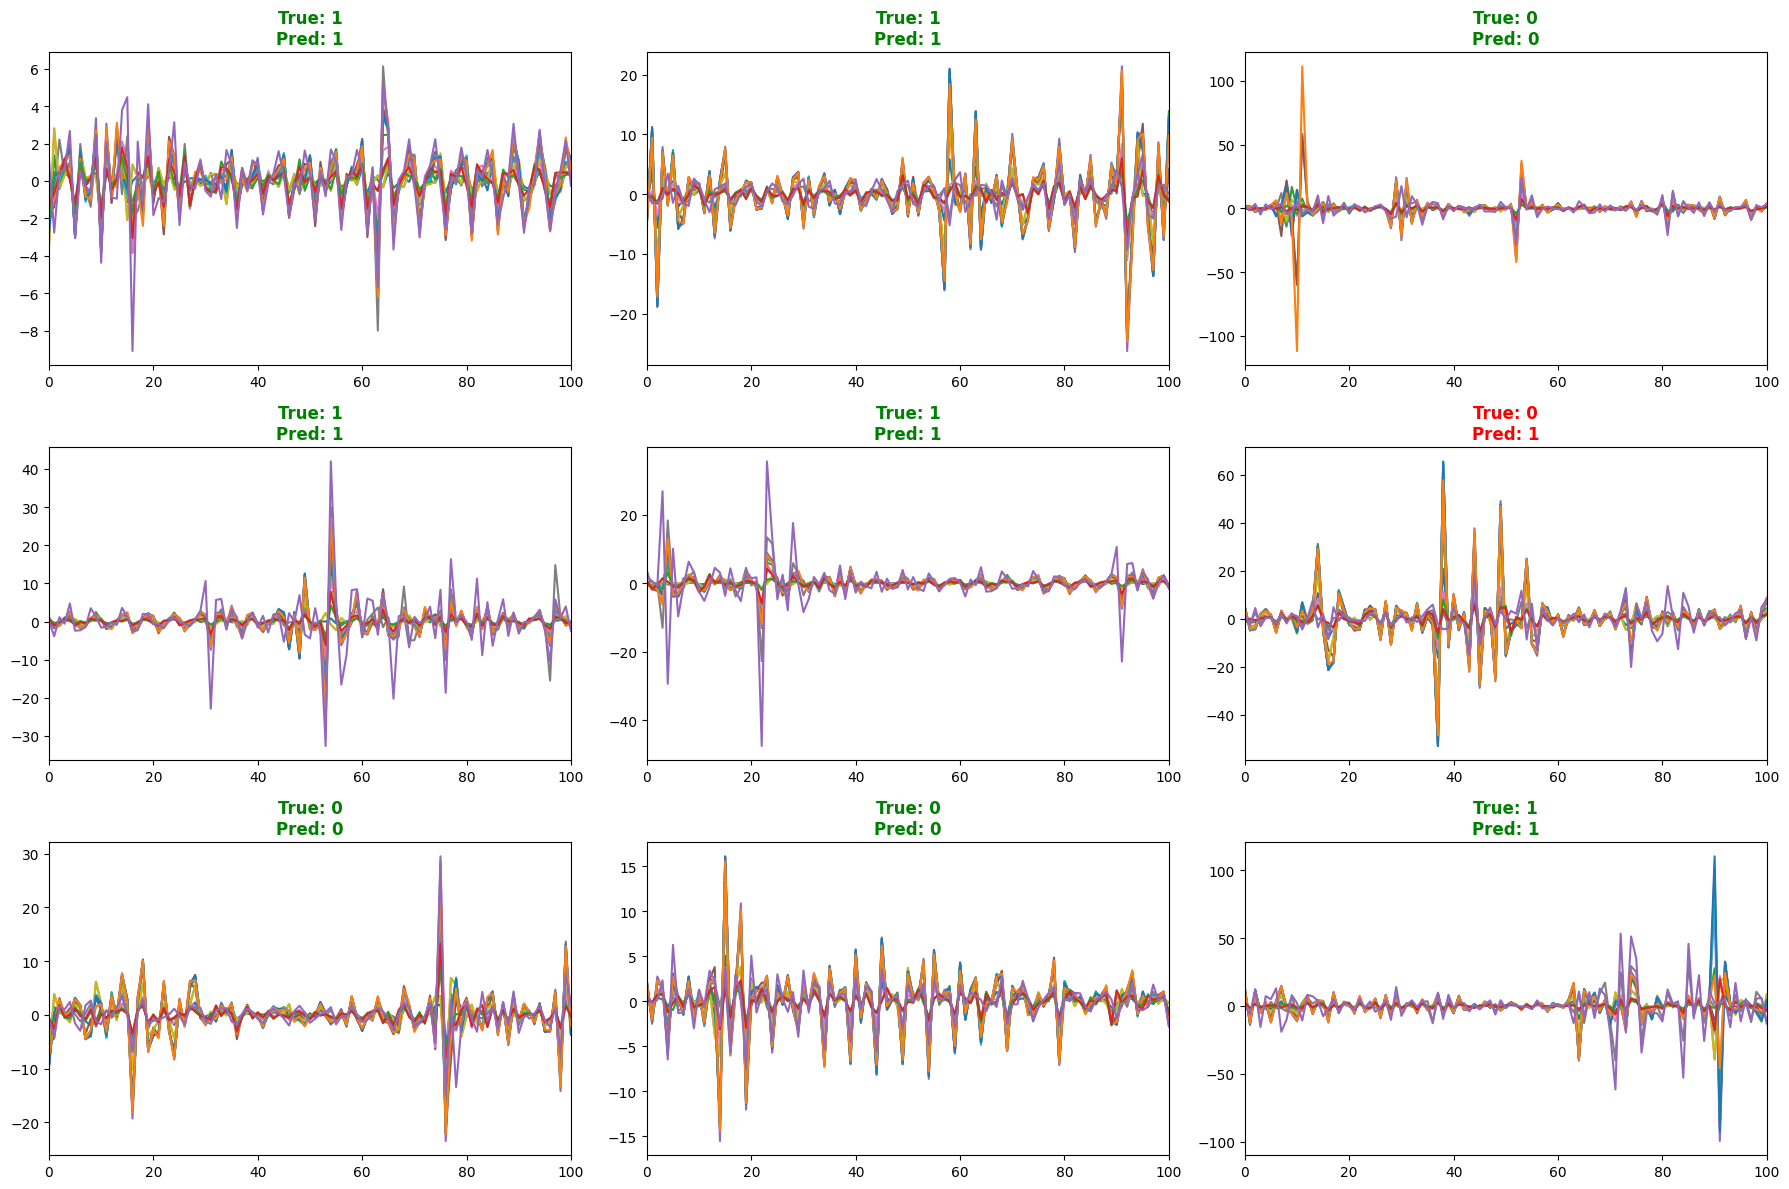

In [32]:
# 显示模型在验证集上的预测结果和真实标签
learn.show_results()

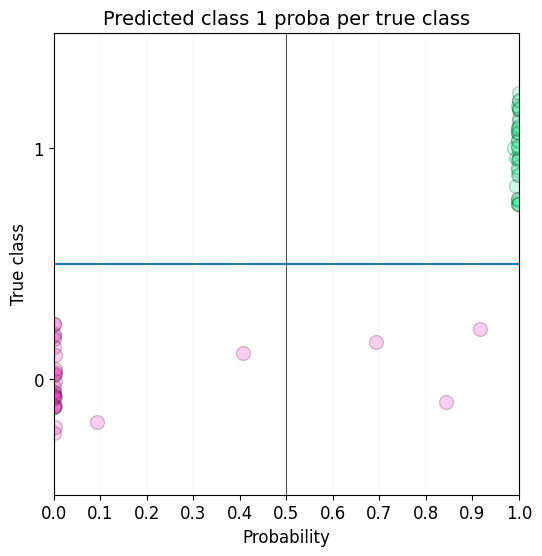

In [33]:
# 显示模型在验证集上的预测概率
learn.show_probas()

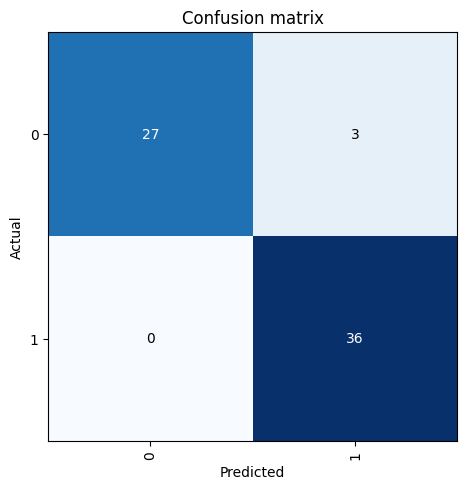

In [34]:
# 绘制混淆矩阵
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()